<a href="https://colab.research.google.com/github/Val-Faria/tech-challenge-ia-saude/blob/marcelo%2Falgoritmo-genetico/02_otimizacao_hiperparametros_ag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Otimização de Modelos de Diagnóstico e Interpretação com IA Generativa
## Tech Challenge - Fase 2 | IA para Devs

Este projeto dá continuidade à solução desenvolvida na fase anterior para classificação de registros clínicos relacionados à tireoide. A proposta combina Algoritmos Genéticos para otimização automática de hiperparâmetros dos modelos de Machine Learning e Large Language Models (LLMs) para interpretação dos resultados em linguagem natural.

O objetivo é melhorar o desempenho dos modelos diagnósticos por meio de técnicas evolucionárias e transformar predições, probabilidades e métricas em explicações mais acessíveis e úteis para profissionais da saúde.

A solução possui caráter acadêmico e experimental. Os resultados gerados devem ser utilizados apenas como apoio à análise clínica, não substituindo a avaliação e o julgamento de profissionais da saúde.

## 1. Preparação do Ambiente

A execução do projeto foi planejada para o Google Colab, permitindo o carregamento automático dos dados e a reprodução dos experimentos em ambiente padronizado. A célula a seguir realiza as configurações iniciais do ambiente e pode incluir a instalação de dependências necessárias para a execução das etapas de otimização por Algoritmos Genéticos e interpretação dos resultados com LLMs.


In [1]:
# Opcional - execute apenas se necessário
# !pip install openai
# !pip install transformers
# !pip install accelerate
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 27.6 MB/s eta 0:00:00


## 2. Importação das Bibliotecas

O projeto utiliza bibliotecas para análise de dados, visualização, treinamento e avaliação de modelos de Machine Learning, além de recursos para implementação do Algoritmo Genético empregado na otimização de hiperparâmetros. O parâmetro `RANDOM_STATE` foi adotado para aumentar a reprodutibilidade dos resultados.


In [39]:
import os
import random
import sys
import time
import urllib.request
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deap import base, creator, tools, algorithms
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COLUMN = "target"
POSITIVE_LABEL = "hypothyroid"
NEGATIVE_LABEL = "negative"

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Seed global definida: {RANDOM_STATE}")


Seed global definida: 42


## 3. Fonte de Dados e Diretórios do Projeto

O dataset hypothyroid_final.csv é carregado automaticamente do GitHub no Google Colab ou da pasta dataset/ em ambiente local. Os diretórios necessários para armazenamento dos resultados são criados durante a execução.

In [3]:
GITHUB_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "mvaraujo1977/TechCahllenge_Tireoide/"
    "Nirton_Afonso/dataset/hypothyroid_final.csv"
)

RUNNING_IN_COLAB = "google.colab" in sys.modules

if RUNNING_IN_COLAB:
    PROJECT_ROOT = Path("/content/TechCahllenge_Tireoide")
    DATA_DIR = PROJECT_ROOT / "dataset"
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "hypothyroid_final.csv"

    print("Ambiente Google Colab detectado.")
    print(f"Baixando dataset do GitHub para: {DATA_PATH}")
    urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name.lower() == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    DATA_PATH = PROJECT_ROOT / "dataset" / "hypothyroid_final.csv"
    if not DATA_PATH.exists():
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        print("Dataset local não encontrado. Baixando do GitHub para a pasta dataset/ do projeto.")
        urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Fonte GitHub: {GITHUB_DATA_URL}")
print(f"Dataset em uso: {DATA_PATH.resolve()}")
print(f"Diretório de modelos: {MODELS_DIR.resolve()}")
print(f"Diretório de figuras: {FIGURES_DIR.resolve()}")
print(f"Diretório de resultados: {RESULTS_DIR.resolve()}")

Ambiente Google Colab detectado.
Baixando dataset do GitHub para: /content/TechCahllenge_Tireoide/dataset/hypothyroid_final.csv
Fonte GitHub: https://raw.githubusercontent.com/mvaraujo1977/TechCahllenge_Tireoide/Nirton_Afonso/dataset/hypothyroid_final.csv
Dataset em uso: /content/TechCahllenge_Tireoide/dataset/hypothyroid_final.csv
Diretório de modelos: /content/TechCahllenge_Tireoide/models
Diretório de figuras: /content/TechCahllenge_Tireoide/reports/figures
Diretório de resultados: /content/TechCahllenge_Tireoide/reports/results


## 4. Carregamento do Dataset

O conjunto de dados será carregado para o treinamento do modelo Random Forest e para a avaliação das diferentes configurações de hiperparâmetros exploradas pelo Algoritmo Genético.

In [4]:
dados = pd.read_csv(DATA_PATH, na_values=["?", "", "NA", "NaN"])

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {dados.shape[0]} linhas × {dados.shape[1]} colunas")

display(dados.head())

Dataset carregado com sucesso!
Dimensões: 3163 linhas × 26 colunas


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN


## 5. Limpeza dos Dados

A limpeza adotou uma postura conservadora, adequada ao contexto médico. Registros duplicados foram removidos para reduzir viés amostral, enquanto valores extremos foram mantidos por sua possível relevância clínica. O tratamento de ausentes foi reservado ao pipeline de modelagem.

In [5]:
dados_limpos = dados.copy()
antes = len(dados_limpos)
dados_limpos = dados_limpos.drop_duplicates().reset_index(drop=True)
depois = len(dados_limpos)

print(f"Registros antes: {antes}")
print(f"Registros após remoção de duplicados: {depois}")
print(f"Duplicados removidos: {antes - depois}")

dados_limpos = dados_limpos[dados_limpos[TARGET_COLUMN].isin([NEGATIVE_LABEL, POSITIVE_LABEL])].reset_index(drop=True)

print("Distribuição após limpeza:")
display(dados_limpos[TARGET_COLUMN].value_counts().to_frame("quantidade"))

Registros antes: 3163
Registros após remoção de duplicados: 3086
Duplicados removidos: 77
Distribuição após limpeza:


,quantidade
target,
negative,2945
hypothyroid,141


In [6]:
checks = []
if "age" in dados_limpos.columns:
    checks.append({
        "variavel": "age",
        "menor_que_zero": int((dados_limpos["age"] < 0).sum()),
        "maior_que_120": int((dados_limpos["age"] > 120).sum()),
    })

for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    if col in dados_limpos.columns:
        checks.append({
            "variavel": col,
            "menor_que_zero": int((dados_limpos[col] < 0).sum()),
            "maior_que_120": np.nan,
        })

display(pd.DataFrame(checks))

,variavel,menor_que_zero,maior_que_120
0,age,0,0.0
1,TSH,0,NaN
2,T3,0,NaN
3,TT4,0,NaN
4,T4U,0,NaN
5,FTI,0,NaN
6,TBG,0,NaN


## 6. Separação entre Variáveis Preditoras e Variável-Alvo

Nesta etapa, o dataset é dividido em variáveis preditoras (`X`) e variável-alvo (`y`). Essa separação é essencial para estruturar o problema de aprendizado supervisionado, permitindo o treinamento do modelo Random Forest e a avaliação das diferentes combinações de hiperparâmetros exploradas pelo Algoritmo Genético.

In [7]:
X = dados_limpos.drop(columns=[TARGET_COLUMN])
y = dados_limpos[TARGET_COLUMN].map({NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1})

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print("Mapeamento: 0 = negative, 1 = hypothyroid")
display(y.value_counts().rename(index={0: NEGATIVE_LABEL, 1: POSITIVE_LABEL}).to_frame("quantidade"))

Formato de X: (3086, 25)
Formato de y: (3086,)
Mapeamento: 0 = negative, 1 = hypothyroid


,quantidade
target,
negative,2945
hypothyroid,141


## 7. Divisão dos Dados

O dataset foi particionado de forma **estratificada** para preservar a proporção original das classes:

* **Treino (70%):** Ajuste e aprendizado do modelo.
* **Validação (15%):** Otimização de hiperparâmetros (Algoritmo Genético) e seleção do modelo.
* **Teste (15%):** Avaliação final e métricas de generalização (dados inéditos).

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

splits_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "quantidade": [len(X_train), len(X_val), len(X_test)],
    "percentual": [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    "positivos": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
splits_summary["percentual"] = (splits_summary["percentual"] * 100).round(2)
display(splits_summary)

,conjunto,quantidade,percentual,positivos
0,treino,2160,69.99,99
1,validação,463,15.00,21
2,teste,463,15.00,21


## 8. Pipeline de Pré-processamento

O pré-processamento foi encapsulado em pipelines do `scikit-learn` para reduzir risco de data leakage. Assim, imputação, padronização e codificação categórica são ajustadas somente no conjunto de treino e aplicadas de forma consistente aos demais subconjuntos.

In [9]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

Variáveis numéricas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
Variáveis categóricas: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


## 9. Modelagem

Como o modelo **Random Forest** apresentou o melhor desempenho preliminar, o foco desta etapa foi direcionado exclusivamente para a otimização de seus hiperparâmetros. Utilizando uma abordagem evolutiva baseada em **Algoritmo Genético**, o espaço de busca foi explorado para maximizar a capacidade de generalização do classificador, mitigando o risco de *overfitting* mapeado nas análises anteriores.

In [10]:
modelos = {
    "Random Forest": Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ])
}

print("Dicionário de modelos atualizado. Foco exclusivo em:", list(modelos.keys()))

Dicionário de modelos atualizado. Foco exclusivo em: ['Random Forest']


In [11]:
def get_positive_scores(model, X_data):
    return model.predict_proba(X_data)[:, 1]

def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)

    # Probabilidade da classe positiva (0.0 a 1.0) para o cálculo do AUC
    y_score = get_positive_scores(model, X_data)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score)
    }

    return metrics, y_pred, y_score

## 10. Avaliação do Modelo Baseline

A definição de um modelo **baseline** foi adotada como referência inicial para mensurar o efeito da otimização dos hiperparâmetros realizada pelo Algoritmo Genético.

O modelo **Random Forest** em sua configuração inicial é avaliado no conjunto de validação, estabelecendo uma linha de comparação para verificar se a busca evolutiva foi capaz de aprimorar seu desempenho preditivo.

In [12]:
nome_modelo = "Random Forest"
pipeline_rf = modelos[nome_modelo]

print(f"Treinando: {nome_modelo}...")
pipeline_rf.fit(X_train, y_train)

modelos_treinados = {nome_modelo: pipeline_rf}

train_metrics, _, _ = evaluate_model(pipeline_rf, X_train, y_train)
val_metrics, y_val_pred, y_val_score = evaluate_model(pipeline_rf, X_val, y_val)

validacao_predicoes = {nome_modelo: {"pred": y_val_pred, "score": y_val_score}}

resultados = [{
    "modelo": nome_modelo,
    "accuracy_treino": train_metrics["accuracy"],
    "recall_treino": train_metrics["recall"],
    "f1_treino": train_metrics["f1"],
    "accuracy_validacao": val_metrics["accuracy"],
    "precision_validacao": val_metrics["precision"],
    "recall_validacao": val_metrics["recall"],
    "f1_validacao": val_metrics["f1"],
    "auc_validacao": val_metrics["auc"]
}]

resultados_df = pd.DataFrame(resultados)

display(resultados_df.style.format({
    col: "{:.3f}" for col in resultados_df.select_dtypes(include=[np.number]).columns
}))

Treinando: Random Forest...


,modelo,accuracy_treino,recall_treino,f1_treino,accuracy_validacao,precision_validacao,recall_validacao,f1_validacao,auc_validacao
0,Random Forest,0.994,1.000,0.934,0.991,0.870,0.952,0.909,0.986


## 11. Definição dos Hiperparâmetros a Serem Otimizados

Foram selecionados os hiperparâmetros do **Random Forest** com maior influência na complexidade, capacidade de generalização e desempenho do modelo.

A escolha desses parâmetros busca permitir que o Algoritmo Genético explore diferentes configurações da floresta, equilibrando a capacidade de aprendizado do modelo e o controle de sobreajuste, sem ampliar excessivamente o espaço de busca e elevar o custo computacional da otimização.

In [13]:
PARAM_BOUNDS = {
    "n_estimators": (50, 350),          # Número de árvores
    "max_depth": (3, 20),               # Profundidade máxima
    "min_samples_split": (2, 12),       # Mínimo para dividir um nó
    "min_samples_leaf": (1, 10),        # Mínimo de amostras na folha
    "max_features": ["sqrt", "log2"]    # Método de sorteio de colunas
}



A escolha de definir o espaço de busca por **intervalos (tuplas)** em vez de uma lista engessada de valores fixos foi adotada porque ela viabiliza a lógica evolutiva do Algoritmo Genético. Essa abordagem permite que os operadores de **mutação** realizem pequenos ajustes incrementais e contínuos nos parâmetros (como refinar o número de árvores de `150` para `153`), eliminando os pontos cegos das buscas tradicionais e garantindo que o algoritmo explore livremente o intervalo para convergir de forma cirúrgica na combinação exata que maximiza a performance do modelo.

#CACHE
Algoritmo Genético com cache, acelera bastante e evita treinar novamente combinações já avaliadas.

In [18]:
# ============================================================
# CACHE DE AVALIAÇÕES DO ALGORITMO GENÉTICO
# ============================================================

fitness_cache = {}

cache_estatisticas = {
    "acertos": 0,
    "novas_avaliacoes": 0
}


def individual_to_key(individual):
    """
    Converte os genes do indivíduo em uma tupla imutável,
    que pode ser utilizada como chave do cache.
    """
    return tuple(int(gene) for gene in individual)

## 12. Função Fitness

A função de avaliação foi definida considerando as características do problema de classificação em saúde e a necessidade de uma avaliação consistente durante a otimização.

A utilização de `clone()` foi escolhida para garantir que cada combinação de hiperparâmetros fosse avaliada de forma independente, evitando que o treinamento de um indivíduo influenciasse a avaliação dos demais e preservando a integridade do pipeline original.

O **Recall** foi adotado como métrica principal de otimização por estar alinhado ao objetivo clínico do projeto: priorizar a identificação dos casos positivos e reduzir a ocorrência de falsos negativos.

As métricas de **Acurácia**, **Precisão**, **F1-Score** e **AUC** foram mantidas para permitir uma análise mais abrangente do modelo otimizado e possibilitar uma comparação posterior com o modelo baseline.

In [19]:
# ============================================================
# 12. FUNÇÃO FITNESS COM CACHE
# ============================================================

def evaluate_individual(individual):

    chave = individual_to_key(individual)

    # --------------------------------------------------------
    # Reutiliza o resultado quando a configuração já foi testada
    # --------------------------------------------------------
    if chave in fitness_cache:

        cache_estatisticas["acertos"] += 1

        resultado_cache = fitness_cache[chave]

        individual.metrics = resultado_cache["metrics"].copy()

        return (resultado_cache["fitness"],)

    cache_estatisticas["novas_avaliacoes"] += 1

    # --------------------------------------------------------
    # Converte os genes em hiperparâmetros do Random Forest
    # --------------------------------------------------------
    params = {
        "classifier__n_estimators": int(individual[0]),
        "classifier__max_depth": int(individual[1]),
        "classifier__min_samples_split": int(individual[2]),
        "classifier__min_samples_leaf": int(individual[3]),
        "classifier__max_features": (
            PARAM_BOUNDS["max_features"][int(individual[4])]
        )
    }

    # Cada indivíduo recebe uma cópia independente do pipeline
    pipeline = clone(modelos["Random Forest"])

    pipeline.set_params(**params)

    # Treinamento apenas no conjunto de treino
    pipeline.fit(X_train, y_train)

    # Avaliação no conjunto de validação
    preds = pipeline.predict(X_val)
    probs = pipeline.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, preds)
    prec = precision_score(
        y_val,
        preds,
        zero_division=0
    )
    rec = recall_score(
        y_val,
        preds,
        zero_division=0
    )
    f1 = f1_score(
        y_val,
        preds,
        zero_division=0
    )
    auc = roc_auc_score(
        y_val,
        probs
    )

    metricas = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

    individual.metrics = metricas.copy()

    # Recall é a função fitness
    fitness = rec

    fitness_cache[chave] = {
        "fitness": fitness,
        "metrics": metricas.copy()
    }

    return (fitness,)

## 13. Implementação do Algoritmo Genético

A implementação do Algoritmo Genético foi definida buscando equilibrar capacidade de exploração do espaço de busca e custo computacional do processo de otimização.

A biblioteca **DEAP** foi escolhida por oferecer uma estrutura flexível para criação dos indivíduos, definição da função fitness e aplicação dos operadores evolutivos, facilitando a adaptação do algoritmo ao problema de ajuste dos hiperparâmetros do Random Forest.

A representação dos indivíduos foi mantida utilizando os hiperparâmetros selecionados anteriormente, permitindo explorar diferentes combinações de configuração do modelo sem realizar uma busca exaustiva.

Os operadores evolutivos foram definidos considerando o equilíbrio entre exploração de novas soluções e aproveitamento das melhores configurações encontradas:

- **Seleção por torneio:** escolhida por manter indivíduos com melhor desempenho, sem eliminar completamente a diversidade da população.
- **Crossover de dois pontos:** adotado por permitir combinar características de diferentes soluções e gerar novas combinações de hiperparâmetros.
- **Mutação uniforme:** utilizada para introduzir variações aleatórias controladas, evitando que o algoritmo fique limitado às soluções inicialmente encontradas.

Os parâmetros de população, número de gerações, crossover e mutação foram avaliados em diferentes configurações experimentais, permitindo analisar o comportamento do algoritmo durante a otimização.

In [22]:
# ============================================================
# 13. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

def run_genetic_algorithm(
    pop_size,
    n_generations,
    crossover_prob,
    mutation_prob,
    seed=RANDOM_STATE
):
    global fitness_cache
    global cache_estatisticas

    inicio = time.time()

    # Reprodutibilidade do experimento
    random.seed(seed)
    np.random.seed(seed)

    # O cache é reiniciado para cada experimento,
    # permitindo uma comparação justa de tempo
    fitness_cache.clear()

    cache_estatisticas = {
        "acertos": 0,
        "novas_avaliacoes": 0
    }

    # Evita erro ao executar novamente a célula no Colab
    if hasattr(creator, "FitnessMax"):
        del creator.FitnessMax

    if hasattr(creator, "Individual"):
        del creator.Individual

    creator.create(
        "FitnessMax",
        base.Fitness,
        weights=(1.0,)
    )

    creator.create(
        "Individual",
        list,
        fitness=creator.FitnessMax
    )

    toolbox = base.Toolbox()

    # --------------------------------------------------------
    # Geração dos genes
    # --------------------------------------------------------
    toolbox.register(
        "attr_n_estimators",
        random.randint,
        *PARAM_BOUNDS["n_estimators"]
    )

    toolbox.register(
        "attr_max_depth",
        random.randint,
        *PARAM_BOUNDS["max_depth"]
    )

    toolbox.register(
        "attr_min_samples_split",
        random.randint,
        *PARAM_BOUNDS["min_samples_split"]
    )

    toolbox.register(
        "attr_min_samples_leaf",
        random.randint,
        *PARAM_BOUNDS["min_samples_leaf"]
    )

    toolbox.register(
        "attr_max_features",
        random.randint,
        0,
        len(PARAM_BOUNDS["max_features"]) - 1
    )

    toolbox.register(
        "individual",
        tools.initCycle,
        creator.Individual,
        (
            toolbox.attr_n_estimators,
            toolbox.attr_max_depth,
            toolbox.attr_min_samples_split,
            toolbox.attr_min_samples_leaf,
            toolbox.attr_max_features,
        ),
        n=1
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register(
        "evaluate",
        evaluate_individual
    )

    toolbox.register(
        "mate",
        tools.cxTwoPoint
    )

    toolbox.register(
        "mutate",
        tools.mutUniformInt,
        low=[
            PARAM_BOUNDS["n_estimators"][0],
            PARAM_BOUNDS["max_depth"][0],
            PARAM_BOUNDS["min_samples_split"][0],
            PARAM_BOUNDS["min_samples_leaf"][0],
            0
        ],
        up=[
            PARAM_BOUNDS["n_estimators"][1],
            PARAM_BOUNDS["max_depth"][1],
            PARAM_BOUNDS["min_samples_split"][1],
            PARAM_BOUNDS["min_samples_leaf"][1],
            len(PARAM_BOUNDS["max_features"]) - 1
        ],
        indpb=0.20
    )

    toolbox.register(
        "select",
        tools.selTournament,
        tournsize=3
    )

    population = toolbox.population(n=pop_size)

    hall_of_fame = tools.HallOfFame(1)

    stats = tools.Statistics(
        lambda individual: individual.fitness.values[0]
    )

    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    population, logbook = algorithms.eaSimple(
        population,
        toolbox,
        cxpb=crossover_prob,
        mutpb=mutation_prob,
        ngen=n_generations,
        stats=stats,
        halloffame=hall_of_fame,
        verbose=False
    )

    best_individual = hall_of_fame[0]
    best_fitness = best_individual.fitness.values[0]

    tempo_execucao = time.time() - inicio

    resultado_execucao = {
        "tempo_execucao": tempo_execucao,
        "avaliacoes_reais": cache_estatisticas["novas_avaliacoes"],
        "resultados_reutilizados": cache_estatisticas["acertos"],
        "tamanho_cache": len(fitness_cache)
    }

    return (
        best_individual,
        best_fitness,
        logbook,
        resultado_execucao
    )

In [29]:
# ============================================================
# EXPERIMENTO 1 - CONFIGURAÇÃO BASE
# ============================================================

print("Iniciando os 3 Experimentos do Algoritmo Genético...\n")

melhor_g1, score_g1, log_g1, execucao_g1 = run_genetic_algorithm(
    pop_size=20,
    n_generations=10,
    crossover_prob=0.7,
    mutation_prob=0.2,
    seed=RANDOM_STATE
)

print("\n================ EXPERIMENTO 1 ================")
print("Configuração:")
print("População: 20")
print("Gerações: 10")
print("Probabilidade de crossover: 70%")
print("Probabilidade de mutação: 20%")

print(f"\nMelhor Recall: {score_g1:.4f}")
print(f"Genes vencedores: {list(melhor_g1)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g1.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g1['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g1['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g1["resultados_reutilizados"]
)

Iniciando os 3 Experimentos do Algoritmo Genético...


================ EXPERIMENTO 1 ================
Configuração:
População: 20
Gerações: 10
Probabilidade de crossover: 70%
Probabilidade de mutação: 20%

Melhor Recall: 0.9524
Genes vencedores: [107, 3, 6, 4, 0]

Métricas do melhor indivíduo:
accuracy: 0.9741
precision: 0.6452
recall: 0.9524
f1: 0.7692
auc: 0.9781

Desempenho da execução:
Tempo: 134.07 segundos
Avaliações reais: 128
Resultados reutilizados pelo cache: 40


In [27]:
# ============================================================
# EXPERIMENTO 2 - MAIOR POPULAÇÃO
# ============================================================

melhor_g2, score_g2, log_g2, execucao_g2 = run_genetic_algorithm(
    pop_size=40,
    n_generations=10,
    crossover_prob=0.8,
    mutation_prob=0.1,
    seed=RANDOM_STATE
)

print("\n================ EXPERIMENTO 2 ================")
print("Configuração:")
print("População: 40")
print("Gerações: 10")
print("Probabilidade de crossover: 80%")
print("Probabilidade de mutação: 10%")

print(f"\nMelhor Recall: {score_g2:.4f}")
print(f"Genes vencedores: {list(melhor_g2)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g2.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g2['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g2['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g2["resultados_reutilizados"]
)


================ EXPERIMENTO 2 ================
Configuração:
População: 40
Gerações: 10
Probabilidade de crossover: 80%
Probabilidade de mutação: 10%

Melhor Recall: 0.9524
Genes vencedores: [107, 3, 6, 4, 0]

Métricas do melhor indivíduo:
accuracy: 0.9741
precision: 0.6452
recall: 0.9524
f1: 0.7692
auc: 0.9781

Desempenho da execução:
Tempo: 327.37 segundos
Avaliações reais: 307
Resultados reutilizados pelo cache: 78


In [28]:
# ============================================================
# EXPERIMENTO 3 - MAIOR TAXA DE MUTAÇÃO
# ============================================================

melhor_g3, score_g3, log_g3, execucao_g3 = run_genetic_algorithm(
    pop_size=20,
    n_generations=10,
    crossover_prob=0.6,
    mutation_prob=0.4,
    seed=RANDOM_STATE
)

print("\n================ EXPERIMENTO 3 ================")
print("Configuração:")
print("População: 20")
print("Gerações: 10")
print("Probabilidade de crossover: 60%")
print("Probabilidade de mutação: 40%")

print(f"\nMelhor Recall: {score_g3:.4f}")
print(f"Genes vencedores: {list(melhor_g3)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g3.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g3['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g3['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g3["resultados_reutilizados"]
)


================ EXPERIMENTO 3 ================
Configuração:
População: 20
Gerações: 10
Probabilidade de crossover: 60%
Probabilidade de mutação: 40%

Melhor Recall: 0.9524
Genes vencedores: [107, 3, 6, 4, 0]

Métricas do melhor indivíduo:
accuracy: 0.9741
precision: 0.6452
recall: 0.9524
f1: 0.7692
auc: 0.9781

Desempenho da execução:
Tempo: 143.69 segundos
Avaliações reais: 129
Resultados reutilizados pelo cache: 33


In [30]:
# ============================================================
# COMPARAÇÃO DOS 3 EXPERIMENTOS
# ============================================================

def traduzir_genes(individuo):
    return {
        "n_estimators": int(individuo[0]),
        "max_depth": int(individuo[1]),
        "min_samples_split": int(individuo[2]),
        "min_samples_leaf": int(individuo[3]),
        "max_features": PARAM_BOUNDS["max_features"][int(individuo[4])]
    }


def resumir_experimento(
    nome,
    individuo,
    execucao,
    populacao,
    geracoes,
    crossover,
    mutacao
):
    metricas = individuo.metrics
    parametros = traduzir_genes(individuo)

    return {
        "Experimento": nome,
        "População": populacao,
        "Gerações": geracoes,
        "Crossover": crossover,
        "Mutação": mutacao,
        "Recall": float(metricas["recall"]),
        "Precision": float(metricas["precision"]),
        "F1-score": float(metricas["f1"]),
        "Accuracy": float(metricas["accuracy"]),
        "AUC": float(metricas["auc"]),
        "Tempo (s)": execucao["tempo_execucao"],
        "Avaliações reais": execucao["avaliacoes_reais"],
        "Cache reutilizado": execucao["resultados_reutilizados"],
        "n_estimators": parametros["n_estimators"],
        "max_depth": parametros["max_depth"],
        "min_samples_split": parametros["min_samples_split"],
        "min_samples_leaf": parametros["min_samples_leaf"],
        "max_features": parametros["max_features"]
    }


comparacao_experimentos = pd.DataFrame([
    resumir_experimento(
        "Experimento 1",
        melhor_g1,
        execucao_g1,
        20,
        10,
        "70%",
        "20%"
    ),
    resumir_experimento(
        "Experimento 2",
        melhor_g2,
        execucao_g2,
        40,
        10,
        "80%",
        "10%"
    ),
    resumir_experimento(
        "Experimento 3",
        melhor_g3,
        execucao_g3,
        20,
        10,
        "60%",
        "40%"
    )
])

comparacao_experimentos = comparacao_experimentos.sort_values(
    by=["Recall", "F1-score", "AUC"],
    ascending=False
).reset_index(drop=True)

comparacao_experimentos.index = comparacao_experimentos.index + 1

print("\n================ COMPARAÇÃO DOS EXPERIMENTOS ================")

display(
    comparacao_experimentos.style.format({
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "F1-score": "{:.4f}",
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Tempo (s)": "{:.2f}"
    })
)


================ COMPARAÇÃO DOS EXPERIMENTOS ================


,Experimento,População,Gerações,Crossover,Mutação,Recall,Precision,F1-score,Accuracy,AUC,Tempo (s),Avaliações reais,Cache reutilizado,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
1,Experimento 1,20,10,70%,20%,0.9524,0.6452,0.7692,0.9741,0.9781,134.07,128,40,107,3,6,4,sqrt
2,Experimento 2,40,10,80%,10%,0.9524,0.6452,0.7692,0.9741,0.9781,327.37,307,78,107,3,6,4,sqrt
3,Experimento 3,20,10,60%,40%,0.9524,0.6452,0.7692,0.9741,0.9781,143.69,129,33,107,3,6,4,sqrt


In [31]:
# ============================================================
# SELEÇÃO DO MELHOR EXPERIMENTO
# ============================================================

experimentos = [
    {
        "nome": "Experimento 1",
        "individuo": melhor_g1,
        "logbook": log_g1,
        "execucao": execucao_g1
    },
    {
        "nome": "Experimento 2",
        "individuo": melhor_g2,
        "logbook": log_g2,
        "execucao": execucao_g2
    },
    {
        "nome": "Experimento 3",
        "individuo": melhor_g3,
        "logbook": log_g3,
        "execucao": execucao_g3
    }
]

melhor_experimento = max(
    experimentos,
    key=lambda exp: (
        exp["individuo"].metrics["recall"],
        exp["individuo"].metrics["f1"],
        exp["individuo"].metrics["auc"]
    )
)

melhor_individuo_global = melhor_experimento["individuo"]
melhores_parametros = traduzir_genes(melhor_individuo_global)

print("\n================ MELHOR EXPERIMENTO ================")
print("Experimento:", melhor_experimento["nome"])
print("Melhores hiperparâmetros:")

for parametro, valor in melhores_parametros.items():
    print(f"- {parametro}: {valor}")

print("\nMétricas na validação:")

for metrica, valor in melhor_individuo_global.metrics.items():
    print(f"- {metrica}: {float(valor):.4f}")


================ MELHOR EXPERIMENTO ================
Experimento: Experimento 1
Melhores hiperparâmetros:
- n_estimators: 107
- max_depth: 3
- min_samples_split: 6
- min_samples_leaf: 4
- max_features: sqrt

Métricas na validação:
- accuracy: 0.9741
- precision: 0.6452
- recall: 0.9524
- f1: 0.7692
- auc: 0.9781


In [32]:
# ============================================================
# GRÁFICOS DE EVOLUÇÃO DOS EXPERIMENTOS
# ============================================================

def logbook_para_dataframe(logbook, nome_experimento):
    df_log = pd.DataFrame(logbook)

    df_log["Experimento"] = nome_experimento

    return df_log


historico_g1 = logbook_para_dataframe(log_g1, "Experimento 1")
historico_g2 = logbook_para_dataframe(log_g2, "Experimento 2")
historico_g3 = logbook_para_dataframe(log_g3, "Experimento 3")

historico_completo = pd.concat(
    [historico_g1, historico_g2, historico_g3],
    ignore_index=True
)

display(historico_completo.head())

,gen,nevals,avg,std,min,max,Experimento
0,0,20,0.952381,0.0,0.952381,0.952381,Experimento 1
1,1,10,0.952381,0.0,0.952381,0.952381,Experimento 1
2,2,17,0.952381,0.0,0.952381,0.952381,Experimento 1
3,3,20,0.952381,0.0,0.952381,0.952381,Experimento 1
4,4,15,0.952381,0.0,0.952381,0.952381,Experimento 1


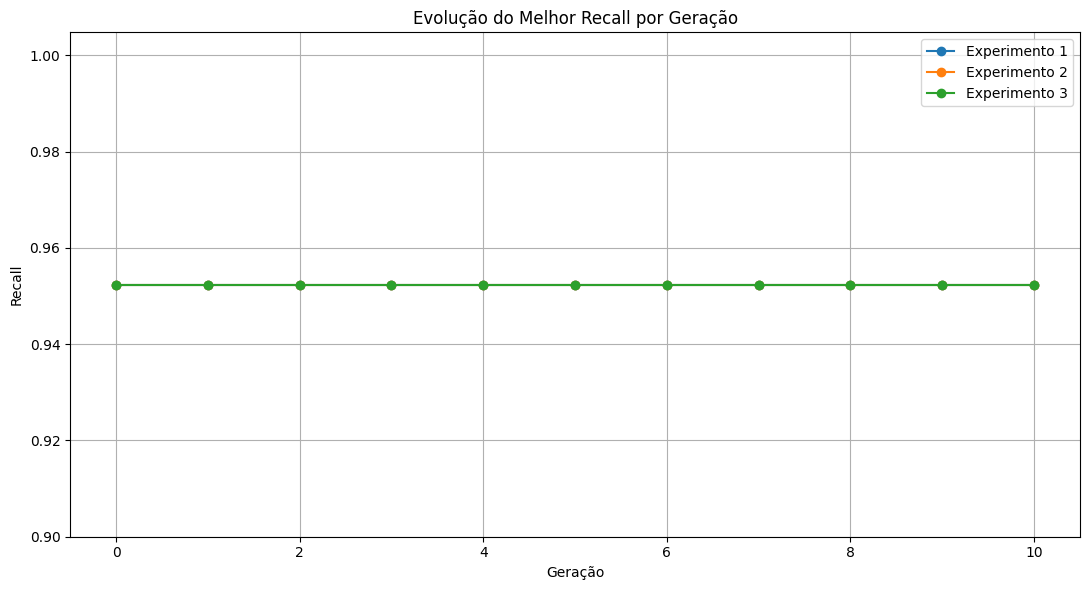

In [33]:
# ============================================================
# EVOLUÇÃO DO MELHOR RECALL
# ============================================================

plt.figure(figsize=(11, 6))

for nome, historico in [
    ("Experimento 1", historico_g1),
    ("Experimento 2", historico_g2),
    ("Experimento 3", historico_g3)
]:
    plt.plot(
        historico["gen"],
        historico["max"],
        marker="o",
        label=nome
    )

plt.title("Evolução do Melhor Recall por Geração")
plt.xlabel("Geração")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_melhor_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

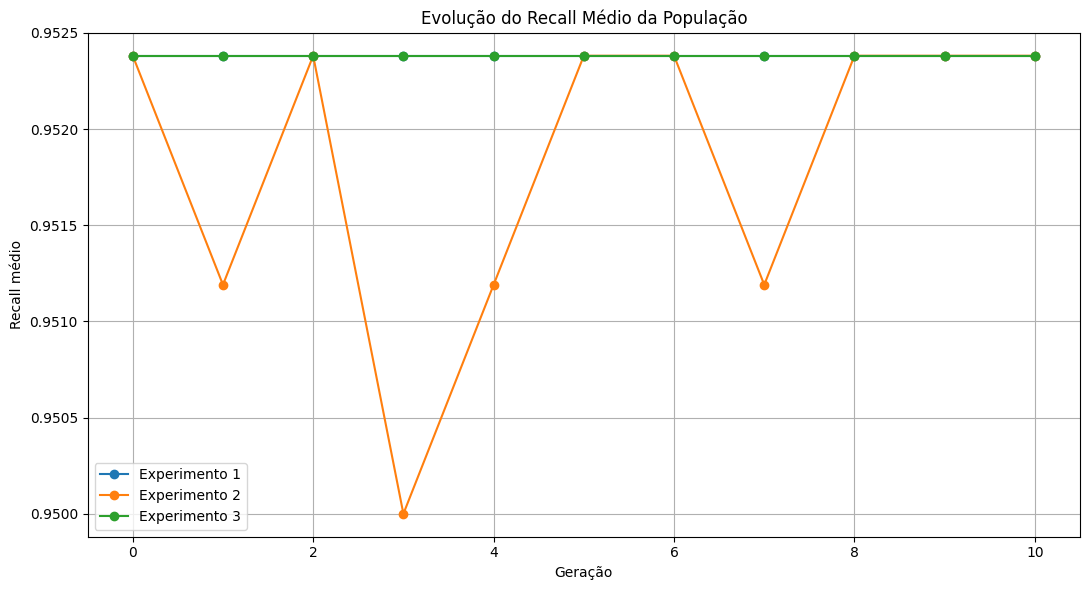

In [34]:
# ============================================================
# EVOLUÇÃO DO RECALL MÉDIO
# ============================================================

plt.figure(figsize=(11, 6))

for nome, historico in [
    ("Experimento 1", historico_g1),
    ("Experimento 2", historico_g2),
    ("Experimento 3", historico_g3)
]:
    plt.plot(
        historico["gen"],
        historico["avg"],
        marker="o",
        label=nome
    )

plt.title("Evolução do Recall Médio da População")
plt.xlabel("Geração")
plt.ylabel("Recall médio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_recall_medio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# ============================================================
# TREINAMENTO DO MODELO FINAL OTIMIZADO
# ============================================================

X_train_final = pd.concat(
    [X_train, X_val],
    axis=0
).reset_index(drop=True)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

modelo_otimizado = clone(modelos["Random Forest"])

parametros_pipeline = {
    f"classifier__{nome}": valor
    for nome, valor in melhores_parametros.items()
}

modelo_otimizado.set_params(**parametros_pipeline)

print("Treinando o modelo otimizado com treino + validação...")

modelo_otimizado.fit(
    X_train_final,
    y_train_final
)

metricas_otimizado_teste, pred_otimizado, score_otimizado = evaluate_model(
    modelo_otimizado,
    X_test,
    y_test
)

print("\nMétricas do modelo otimizado no conjunto de teste:")

for metrica, valor in metricas_otimizado_teste.items():
    print(f"- {metrica}: {valor:.4f}")

Treinando o modelo otimizado com treino + validação...

Métricas do modelo otimizado no conjunto de teste:
- accuracy: 0.9741
- precision: 0.6452
- recall: 0.9524
- f1: 0.7692
- auc: 0.9949


In [36]:
# ============================================================
# AVALIAÇÃO FINAL DO MODELO BASELINE
# ============================================================

modelo_baseline_final = clone(modelos["Random Forest"])

modelo_baseline_final.fit(
    X_train_final,
    y_train_final
)

metricas_baseline_teste, pred_baseline, score_baseline = evaluate_model(
    modelo_baseline_final,
    X_test,
    y_test
)

print("\nMétricas do baseline no conjunto de teste:")

for metrica, valor in metricas_baseline_teste.items():
    print(f"- {metrica}: {valor:.4f}")


Métricas do baseline no conjunto de teste:
- accuracy: 0.9914
- precision: 0.9048
- recall: 0.9048
- f1: 0.9048
- auc: 0.9942


In [37]:
# ============================================================
# COMPARAÇÃO FINAL - BASELINE X MODELO OTIMIZADO
# ============================================================

comparacao_final = pd.DataFrame([
    {
        "Modelo": "Random Forest Baseline",
        "Accuracy": metricas_baseline_teste["accuracy"],
        "Precision": metricas_baseline_teste["precision"],
        "Recall": metricas_baseline_teste["recall"],
        "F1-score": metricas_baseline_teste["f1"],
        "AUC": metricas_baseline_teste["auc"]
    },
    {
        "Modelo": "Random Forest Otimizado",
        "Accuracy": metricas_otimizado_teste["accuracy"],
        "Precision": metricas_otimizado_teste["precision"],
        "Recall": metricas_otimizado_teste["recall"],
        "F1-score": metricas_otimizado_teste["f1"],
        "AUC": metricas_otimizado_teste["auc"]
    }
])

print("\n================ COMPARAÇÃO FINAL ================")

display(
    comparacao_final.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

comparacao_final.to_csv(
    RESULTS_DIR / "comparacao_baseline_otimizado.csv",
    index=False
)


================ COMPARAÇÃO FINAL ================


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Random Forest Baseline,0.9914,0.9048,0.9048,0.9048,0.9942
1,Random Forest Otimizado,0.9741,0.6452,0.9524,0.7692,0.9949


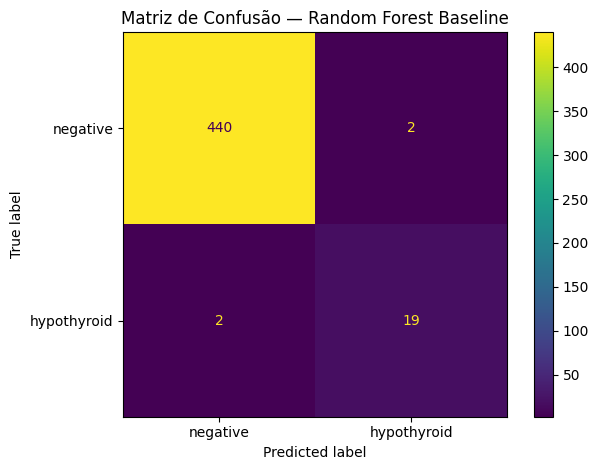

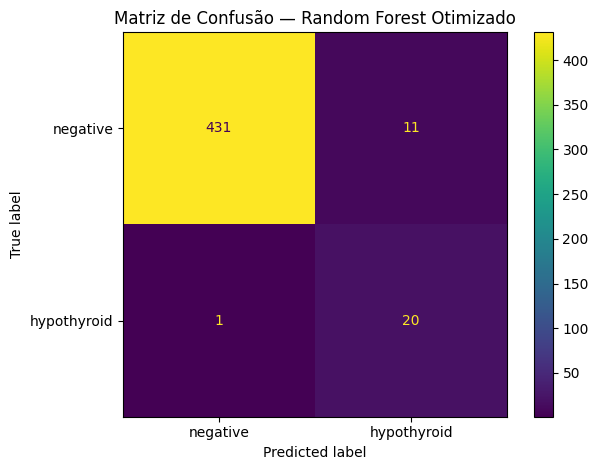

In [40]:
# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_baseline,
    display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest Baseline")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "matriz_confusao_baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_otimizado,
    display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest Otimizado")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "matriz_confusao_otimizado.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
# ============================================================
# SALVAR O MODELO FINAL
# ============================================================

CAMINHO_MODELO = MODELS_DIR / "random_forest_otimizado.joblib"

joblib.dump(
    modelo_otimizado,
    CAMINHO_MODELO
)

print(f"Modelo salvo em: {CAMINHO_MODELO.resolve()}")

Modelo salvo em: /content/TechCahllenge_Tireoide/models/random_forest_otimizado.joblib
